# Financial Factors 教程

本教程介绍 open-xquant 财务因子数据层的核心用法：下载上市公司财务报表数据（A 股 + 美股），读取并用于因子计算。

财务数据层采用 **FactorFetcher + FactorDownloader** 架构：
- **FactorFetcher** — 统一的数据源接口（Protocol），每个数据源实现一个 Fetcher
- **FactorDownloader** — 通用存储层，负责标准化 + 保存 Parquet + 增量合并
- **read_factor()** — 读取本地数据，支持 `point_in_time` 防止回测未来函数偏差

### 支持的财务因子

| 因子 | 说明 | 来源报表 |
|------|------|----------|
| `eps` | 每股收益 | 利润表 |
| `revenue` | 营业收入 | 利润表 |
| `net_income` | 净利润 | 利润表 |
| `roe` | 净资产收益率 | 利润表+资产负债表 |
| `total_assets` | 资产总计 | 资产负债表 |
| `book_value_per_share` | 每股净资产 | 资产负债表 |
| `operating_cash_flow` | 经营现金流 | 现金流量表 |
| `total_shares` | 总股本 | 股本数据 |

## 1. 安装依赖

```bash
# A 股财务数据（通过 akshare 从东方财富获取）
pip install open-xquant[akshare]

# 美股财务数据（通过 yfinance）
pip install open-xquant[yfinance]

# 两者都安装
pip install open-xquant[akshare,yfinance]
```

---
## 2. 下载 A 股财务数据（东方财富）

使用 `EastMoneyFetcher` + `FactorDownloader` 下载 A 股财务报表数据。

In [15]:
from oxq.data import EastMoneyFetcher, FactorDownloader

# 创建 Fetcher（数据源）+ Downloader（存储层）
fetcher = EastMoneyFetcher()
dl = FactorDownloader(fetcher, sub="financial")

# 下载贵州茅台 2023-2024 年财务数据
path = dl.download("600519", start="2023-01-01", end="2024-12-31")
print(f"数据已保存到: {path}")

数据已保存到: /Users/daodao/.oxq/data/factor/financial/600519.parquet


查看下载的数据：

In [16]:
import pandas as pd

df = pd.read_parquet(path)
print(f"报告期数量: {len(df)}")
print(f"时间范围: {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"列: {list(df.columns)}")
print()
df

报告期数量: 11
时间范围: 2020-12-31 ~ 2024-12-31
列: ['publish_date', 'net_income', 'eps', 'roe', 'revenue', 'operating_cash_flow', 'book_value_per_share', 'total_assets', 'total_shares', 'period']



,publish_date,net_income,eps,roe,revenue,operating_cash_flow,book_value_per_share,total_assets,total_shares,period
report_date,,,,,,,,,,
2020-12-31,NaT,4.952333e+10,37.17,31.41,9.799324e+10,5.166907e+10,128.421443,2.236242e+11,1.306018e+09,annual
2021-12-31,NaT,5.572053e+10,41.76,29.90,1.094643e+11,6.402868e+10,150.883379,2.630297e+11,1.305363e+09,annual
2022-12-31,NaT,6.537604e+10,49.93,30.26,1.275540e+11,3.669860e+10,157.225774,2.697940e+11,1.303464e+09,annual
2023-03-31,NaT,2.152473e+10,16.55,10.00,3.937930e+10,5.244796e+09,173.759014,2.793736e+11,1.303320e+09,quarterly
2023-06-30,NaT,3.733197e+10,28.64,16.70,7.098721e+10,3.038718e+10,159.939870,2.605665e+11,1.308288e+09,quarterly
2023-09-30,NaT,5.482717e+10,42.09,24.82,1.053159e+11,5.000201e+10,173.387204,2.799007e+11,1.297782e+09,quarterly
2023-12-31,NaT,7.752148e+10,59.49,34.19,1.505603e+11,6.659325e+10,171.683608,2.853980e+11,1.302725e+09,annual
2024-03-31,NaT,2.488235e+10,19.16,10.57,4.648474e+10,9.187422e+09,190.839202,3.046531e+11,1.302336e+09,quarterly
2024-06-30,NaT,4.317691e+10,33.19,17.63,8.345116e+10,3.662183e+10,173.997764,2.898356e+11,1.310619e+09,quarterly


每行是一个报告期的财务数据，包含：

- **report_date**（index）— 报告期日期（如 2024-06-30）
- **publish_date** — 财报实际发布日期（当前数据源暂为 NaT，需用户自行补充）
- **period** — "quarterly" 或 "annual"
- 8 个财务因子列

> **重要**: `report_date` 和 `publish_date` 的分离是框架的核心设计。财报发布日期通常比报告期晚 1-2 个月，因子回测时必须使用 `publish_date` 来避免未来函数偏差。当前 EastMoney 和 yfinance 数据源均未提供 `publish_date`（为 NaT），后续章节会演示如何手动补充。

---
## 3. 下载美股财务数据（yfinance）

美股数据通过 `YFinanceFinancialFetcher` 获取，接口完全一致。

In [17]:
from oxq.data import YFinanceFinancialFetcher

us_fetcher = YFinanceFinancialFetcher()
us_dl = FactorDownloader(us_fetcher, sub="financial")

# 下载 Apple 2023-2024 年财务数据
path_aapl = us_dl.download("AAPL", start="2023-01-01", end="2024-12-31")
print(f"数据已保存到: {path_aapl}")

数据已保存到: /Users/daodao/.oxq/data/factor/financial/AAPL.parquet


In [18]:
df_aapl = pd.read_parquet(path_aapl)
print(f"报告期数量: {len(df_aapl)}")
print()
df_aapl

报告期数量: 3



,publish_date,period,eps,revenue,net_income,total_assets,operating_cash_flow,total_shares,roe,book_value_per_share
report_date,,,,,,,,,,
2024-06-30,NaT,quarterly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-30,NaT,quarterly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31,NaT,annual,2.41,1.243000e+11,3.633000e+10,3.440850e+11,2.993500e+10,1.503787e+10,0.544204,4.439324


注意美股数据的两个特点：

1. **`publish_date` 为 NaT** — yfinance 不提供财报发布日期，需要用户自行补充
2. **`roe` 和 `book_value_per_share` 是计算值** — `roe = net_income / equity`，`bvps = equity / shares`

---
## 4. 读取财务数据（read_factor）

下载完成后，使用 `read_factor()` 读取本地数据。指定 `sub="financial"` 读取财务因子数据。

In [19]:
from oxq.data import read_factor

# 读取贵州茅台全部财务数据
moutai = read_factor("600519", sub="financial")
print(f"报告期数量: {len(moutai)}")
print(f"列: {list(moutai.columns)}")
print()
moutai[["eps", "revenue", "roe"]]

报告期数量: 11
列: ['publish_date', 'net_income', 'eps', 'roe', 'revenue', 'operating_cash_flow', 'book_value_per_share', 'total_assets', 'total_shares', 'period']



,eps,revenue,roe
report_date,,,
2020-12-31,37.17,9.799324e+10,31.41
2021-12-31,41.76,1.094643e+11,29.90
2022-12-31,49.93,1.275540e+11,30.26
2023-03-31,16.55,3.937930e+10,10.00
2023-06-30,28.64,7.098721e+10,16.70
2023-09-30,42.09,1.053159e+11,24.82
2023-12-31,59.49,1.505603e+11,34.19
2024-03-31,19.16,4.648474e+10,10.57
2024-06-30,33.19,8.345116e+10,17.63


### 4.1 筛选特定因子

通过 `indicators` 参数只读取需要的因子列：

In [20]:
# 只读取 EPS 和 ROE
selected = read_factor("600519", sub="financial", indicators=["eps", "roe"])
print("筛选后的列:", list(selected.columns))
print()
selected

筛选后的列: ['eps', 'roe', 'publish_date', 'period']



,eps,roe,publish_date,period
report_date,,,,
2020-12-31,37.17,31.41,NaT,annual
2021-12-31,41.76,29.90,NaT,annual
2022-12-31,49.93,30.26,NaT,annual
2023-03-31,16.55,10.00,NaT,quarterly
2023-06-30,28.64,16.70,NaT,quarterly
2023-09-30,42.09,24.82,NaT,quarterly
2023-12-31,59.49,34.19,NaT,annual
2024-03-31,19.16,10.57,NaT,quarterly
2024-06-30,33.19,17.63,NaT,quarterly


注意 `publish_date` 和 `period` 元数据列始终保留，不会被筛选掉。

### 4.2 只读取年报数据

下载时通过 `period` 参数控制：

In [21]:
# 只下载年报数据
annual_path = dl.download("600519", start="2020-01-01", end="2024-12-31", period="annual")
df_annual = pd.read_parquet(annual_path)
print("年报数据:")
df_annual[["period", "eps", "revenue", "roe"]]

年报数据:


,period,eps,revenue,roe
report_date,,,,
2020-12-31,annual,37.17,9.799324e+10,31.41
2021-12-31,annual,41.76,1.094643e+11,29.90
2022-12-31,annual,49.93,1.275540e+11,30.26
2023-03-31,quarterly,16.55,3.937930e+10,10.00
2023-06-30,quarterly,28.64,7.098721e+10,16.70
2023-09-30,quarterly,42.09,1.053159e+11,24.82
2023-12-31,annual,59.49,1.505603e+11,34.19
2024-03-31,quarterly,19.16,4.648474e+10,10.57
2024-06-30,quarterly,33.19,8.345116e+10,17.63


---
## 5. Point-in-Time — 防止未来函数偏差

这是财务因子数据层最重要的设计。

**问题**: 贵州茅台 2024 年 Q2 财报（report_date = 2024-06-30）实际于 2024-08-24 才发布。如果回测时在 2024-07-01 就用了这个数据，就会产生 **未来函数偏差（look-ahead bias）**。

**解决**: 使用 `point_in_time=True` 让 `read_factor()` 按 `publish_date` 而非 `report_date` 筛选数据。

> **注意**: 当前 EastMoney 和 yfinance 数据源暂不提供 `publish_date`（值为 NaT）。下面演示如何手动补充 `publish_date` 并使用 `point_in_time` 功能。

In [22]:
# 读取已下载的数据，手动补充 publish_date
moutai_pit = read_factor("600519", sub="financial")

# 手动补充公告日期（实际生产中可从公告数据库批量获取）
# A 股规则：Q1 在 4 月底前，半年报在 8 月底前，Q3 在 10 月底前，年报在 4 月底前
publish_dates = {
    "2023-03-31": "2023-04-28",
    "2023-06-30": "2023-08-10",
    "2023-09-30": "2023-10-26",
    "2024-03-31": "2024-04-25",
    "2024-06-30": "2024-08-24",
    "2024-09-30": "2024-10-28",
}
for report_dt, pub_dt in publish_dates.items():
    ts = pd.Timestamp(report_dt)
    if ts in moutai_pit.index:
        moutai_pit.loc[ts, "publish_date"] = pd.Timestamp(pub_dt)

# 保存回 parquet（覆盖），这样 read_factor 就能用 point_in_time 了
from oxq.data.factors import resolve_factor_dir
path = resolve_factor_dir(sub="financial") / "600519.parquet"
moutai_pit.to_parquet(path)

print("补充 publish_date 后:")
print(moutai_pit[["publish_date", "eps", "roe"]].to_string())
print()

# 现在 point_in_time 可以工作了
# 假设当前时间是 2024-07-15，此时 Q2 报告还未发布

# 错误做法：按 report_date 筛选，会包含尚未发布的 Q2 数据
df_wrong = read_factor(
    "600519", sub="financial",
    end="2024-07-15",
    point_in_time=False,
)
print(f"❌ 按 report_date 筛选: {len(df_wrong)} 条数据")
print(f"   最新报告期: {df_wrong.index[-1].date()}")
print()

# 正确做法：按 publish_date 筛选，只获取已发布的数据
df_correct = read_factor(
    "600519", sub="financial",
    end="2024-07-15",
    point_in_time=True,
)
print(f"✅ 按 publish_date 筛选: {len(df_correct)} 条数据")
print(f"   最新报告期: {df_correct.index[-1].date()}")
print(f"   发布日期: {df_correct['publish_date'].iloc[-1].date()} (在 2024-07-15 之前)")

补充 publish_date 后:
            publish_date    eps    roe
report_date                           
2020-12-31           NaT  37.17  31.41
2021-12-31           NaT  41.76  29.90
2022-12-31           NaT  49.93  30.26
2023-03-31    2023-04-28  16.55  10.00
2023-06-30    2023-08-10  28.64  16.70
2023-09-30    2023-10-26  42.09  24.82
2023-12-31           NaT  59.49  34.19
2024-03-31    2024-04-25  19.16  10.57
2024-06-30    2024-08-24  33.19  17.63
2024-09-30    2024-10-28  48.42  26.09
2024-12-31           NaT  68.64  36.02

❌ 按 report_date 筛选: 9 条数据
   最新报告期: 2024-06-30

✅ 按 publish_date 筛选: 4 条数据
   最新报告期: 2024-03-31
   发布日期: 2024-04-25 (在 2024-07-15 之前)


---
## 6. 统一的 FactorFetcher Protocol

所有因子数据源都实现了 `FactorFetcher` Protocol，接口完全一致：

In [23]:
from oxq.data import EastMoneyFetcher, YFinanceFinancialFetcher, WorldBankFetcher, FactorFetcher

# 三个 Fetcher 都实现了相同的 Protocol
for cls in [EastMoneyFetcher, YFinanceFinancialFetcher, WorldBankFetcher]:
    instance = cls()
    print(f"{cls.__name__}:")
    print(f"  满足 FactorFetcher Protocol: {isinstance(instance, FactorFetcher)}")
    print(f"  支持的因子: {instance.list_indicators()}")
    print()

EastMoneyFetcher:
  满足 FactorFetcher Protocol: True
  支持的因子: ['book_value_per_share', 'eps', 'net_income', 'operating_cash_flow', 'revenue', 'roe', 'total_assets', 'total_shares']

YFinanceFinancialFetcher:
  满足 FactorFetcher Protocol: True
  支持的因子: ['book_value_per_share', 'eps', 'net_income', 'operating_cash_flow', 'revenue', 'roe', 'total_assets', 'total_shares']

WorldBankFetcher:
  满足 FactorFetcher Protocol: True
  支持的因子: ['cpi', 'gdp', 'gdp_growth', 'gdp_per_capita']



这意味着你可以用相同的代码处理任意数据源：

```python
def download_financial(fetcher: FactorFetcher, symbols: list[str]):
    dl = FactorDownloader(fetcher, sub="financial")
    for sym in symbols:
        dl.download(sym, "2023-01-01", "2024-12-31")

# A 股
download_financial(EastMoneyFetcher(), ["600519", "000858", "601318"])

# 美股
download_financial(YFinanceFinancialFetcher(), ["AAPL", "MSFT", "GOOGL"])
```

---
## 7. 批量下载多只股票

In [24]:
# 批量下载多只美股
us_symbols = ["AAPL", "MSFT", "GOOGL"]
paths = us_dl.download_many(us_symbols, start="2023-01-01", end="2024-12-31")

for sym, p in paths.items():
    df = pd.read_parquet(p)
    latest = df.iloc[-1]
    print(f"{sym}: EPS={latest.get('eps', 'N/A')}, Revenue={latest.get('revenue', 'N/A'):.2e}")

AAPL: EPS=2.41, Revenue=1.24e+11
MSFT: EPS=3.24, Revenue=6.96e+10
GOOGL: EPS=2.17, Revenue=9.65e+10


---
## 8. 增量更新

再次调用 `download()` 时，新数据会与已有数据自动合并去重：

In [25]:
# 第一次下载: 2023 年
dl.download("000858", start="2023-01-01", end="2023-12-31")
df1 = read_factor("000858", sub="financial")
print(f"第一次下载: {len(df1)} 个报告期")

# 第二次下载: 2024 年（自动合并）
dl.download("000858", start="2024-01-01", end="2024-12-31")
df2 = read_factor("000858", sub="financial")
print(f"合并后: {len(df2)} 个报告期")

第一次下载: 6 个报告期
合并后: 6 个报告期


---
## 9. 实战示例：计算简单因子

利用财务数据计算一些常见的基本面因子。这里以贵州茅台为例。

In [26]:
moutai = read_factor("600519", sub="financial")

# 1. 净利润率 = net_income / revenue
moutai["net_profit_margin"] = moutai["net_income"] / moutai["revenue"]

# 2. 应计比率 = (net_income - operating_cash_flow) / total_assets
moutai["accrual_ratio"] = (
    (moutai["net_income"] - moutai["operating_cash_flow"]) / moutai["total_assets"]
)

# 3. 现金流比率 = operating_cash_flow / total_assets
moutai["cash_flow_ratio"] = moutai["operating_cash_flow"] / moutai["total_assets"]

print("贵州茅台 基本面因子:")
moutai[["eps", "roe", "net_profit_margin", "accrual_ratio", "cash_flow_ratio"]]

贵州茅台 基本面因子:


,eps,roe,net_profit_margin,accrual_ratio,cash_flow_ratio
report_date,,,,,
2020-12-31,37.17,31.41,0.505375,-0.009595,0.231053
2021-12-31,41.76,29.90,0.509029,-0.031586,0.243428
2022-12-31,49.93,30.26,0.512536,0.106294,0.136024
2023-03-31,16.55,10.00,0.546600,0.058273,0.018773
2023-06-30,28.64,16.70,0.525897,0.026653,0.116620
2023-09-30,42.09,24.82,0.520597,0.017239,0.178642
2023-12-31,59.49,34.19,0.514886,0.038291,0.233335
2024-03-31,19.16,10.57,0.535280,0.051517,0.030157
2024-06-30,33.19,17.63,0.517391,0.022617,0.126354


上面用手动公式演示了因子计算的原理。但在实际使用中，open-xquant 提供了 **10 个内置 Indicator**，无需手写公式。

In [27]:
from oxq.data import AkShareDownloader, read_factor

# Step 1: 下载贵州茅台量价数据
ak_dl = AkShareDownloader()
price_path = ak_dl.download("600519", start="20230101", end="20241231")

# Step 2: 读取量价数据 + 财务数据
prices = pd.read_parquet(price_path)
financials = read_factor("600519", sub="financial")

print(f"量价数据: {len(prices)} 个交易日, {prices.index[0].date()} ~ {prices.index[-1].date()}")
print(f"财务数据: {len(financials)} 个报告期")
print()

# Step 3: 合并 — 将季度财务数据前向填充到每个交易日
# 财务数据按 report_date 对齐到量价数据的日期轴，向前填充 (ffill)
factor_cols = ["eps", "book_value_per_share", "total_shares",
               "net_income", "operating_cash_flow", "total_assets",
               "revenue", "roe"]
merged = prices.copy()
for col in factor_cols:
    if col in financials.columns:
        # reindex 到交易日，ffill 填充季度间的空白
        merged[col] = financials[col].reindex(merged.index, method="ffill")

print(f"合并后 DataFrame: {merged.shape}")
print(f"列: {list(merged.columns)}")
print()
merged.tail()

量价数据: 484 个交易日, 2023-01-03 ~ 2024-12-31
财务数据: 11 个报告期

合并后 DataFrame: (484, 13)
列: ['open', 'high', 'low', 'close', 'volume', 'eps', 'book_value_per_share', 'total_shares', 'net_income', 'operating_cash_flow', 'total_assets', 'revenue', 'roe']



,open,high,low,close,volume,eps,book_value_per_share,total_shares,net_income,operating_cash_flow,total_assets,revenue,roe
date,,,,,,,,,,,,,
2024-12-25,1487.24,1487.24,1474.54,1478.44,17123,48.42,189.229319,1.308931e+09,6.303146e+10,4.442139e+10,3.056482e+11,1.231225e+11,26.09
2024-12-26,1482.44,1487.22,1471.44,1476.23,18287,48.42,189.229319,1.308931e+09,6.303146e+10,4.442139e+10,3.056482e+11,1.231225e+11,26.09
2024-12-27,1477.34,1484.44,1467.94,1477.41,20759,48.42,189.229319,1.308931e+09,6.303146e+10,4.442139e+10,3.056482e+11,1.231225e+11,26.09
2024-12-30,1482.41,1492.40,1473.44,1473.44,25130,48.42,189.229319,1.308931e+09,6.303146e+10,4.442139e+10,3.056482e+11,1.231225e+11,26.09
2024-12-31,1473.84,1493.44,1470.45,1472.44,39354,68.64,185.564713,1.304188e+09,8.933473e+10,9.246369e+10,3.082714e+11,1.741441e+11,36.02


In [28]:
from oxq.core.registry import list_indicators

# 获取所有已注册的 Indicator
all_indicators = list_indicators()

# 使用内置 Indicator 计算所有 10 个基本面因子
indicator_names = [
    "PE", "PB", "EP", "BP",
    "TurnoverRate", "MarketCap",
    "AccrualRatio", "CashFlowRatio", "NetProfitMargin", "ROEChange",
]

for name in indicator_names:
    indicator_cls = all_indicators[name]
    indicator = indicator_cls()
    try:
        merged[name] = indicator.compute(merged)
    except KeyError as e:
        print(f"  {name}: 跳过 (缺少列 {e})")

print("计算完成! 新增列:")
for name in indicator_names:
    if name in merged.columns:
        valid = merged[name].dropna()
        if len(valid) > 0:
            print(f"  {name}: {valid.iloc[-1]:.4f} (最新值)")
        else:
            print(f"  {name}: 全为 NaN")

计算完成! 新增列:
  PE: 21.4516 (最新值)
  PB: 7.9349 (最新值)
  EP: 0.0466 (最新值)
  BP: 0.1260 (最新值)
  TurnoverRate: 0.0000 (最新值)
  MarketCap: 1920338921528.5571 (最新值)
  AccrualRatio: -0.0102 (最新值)
  CashFlowRatio: 0.2999 (最新值)
  NetProfitMargin: 0.5130 (最新值)
  ROEChange: 9.9300 (最新值)


### 9.2 量价 + 财务因子可视化

将收盘价与 PE、PB 等基本面 Indicator 绘制在同一图表中，观察它们的联动关系。

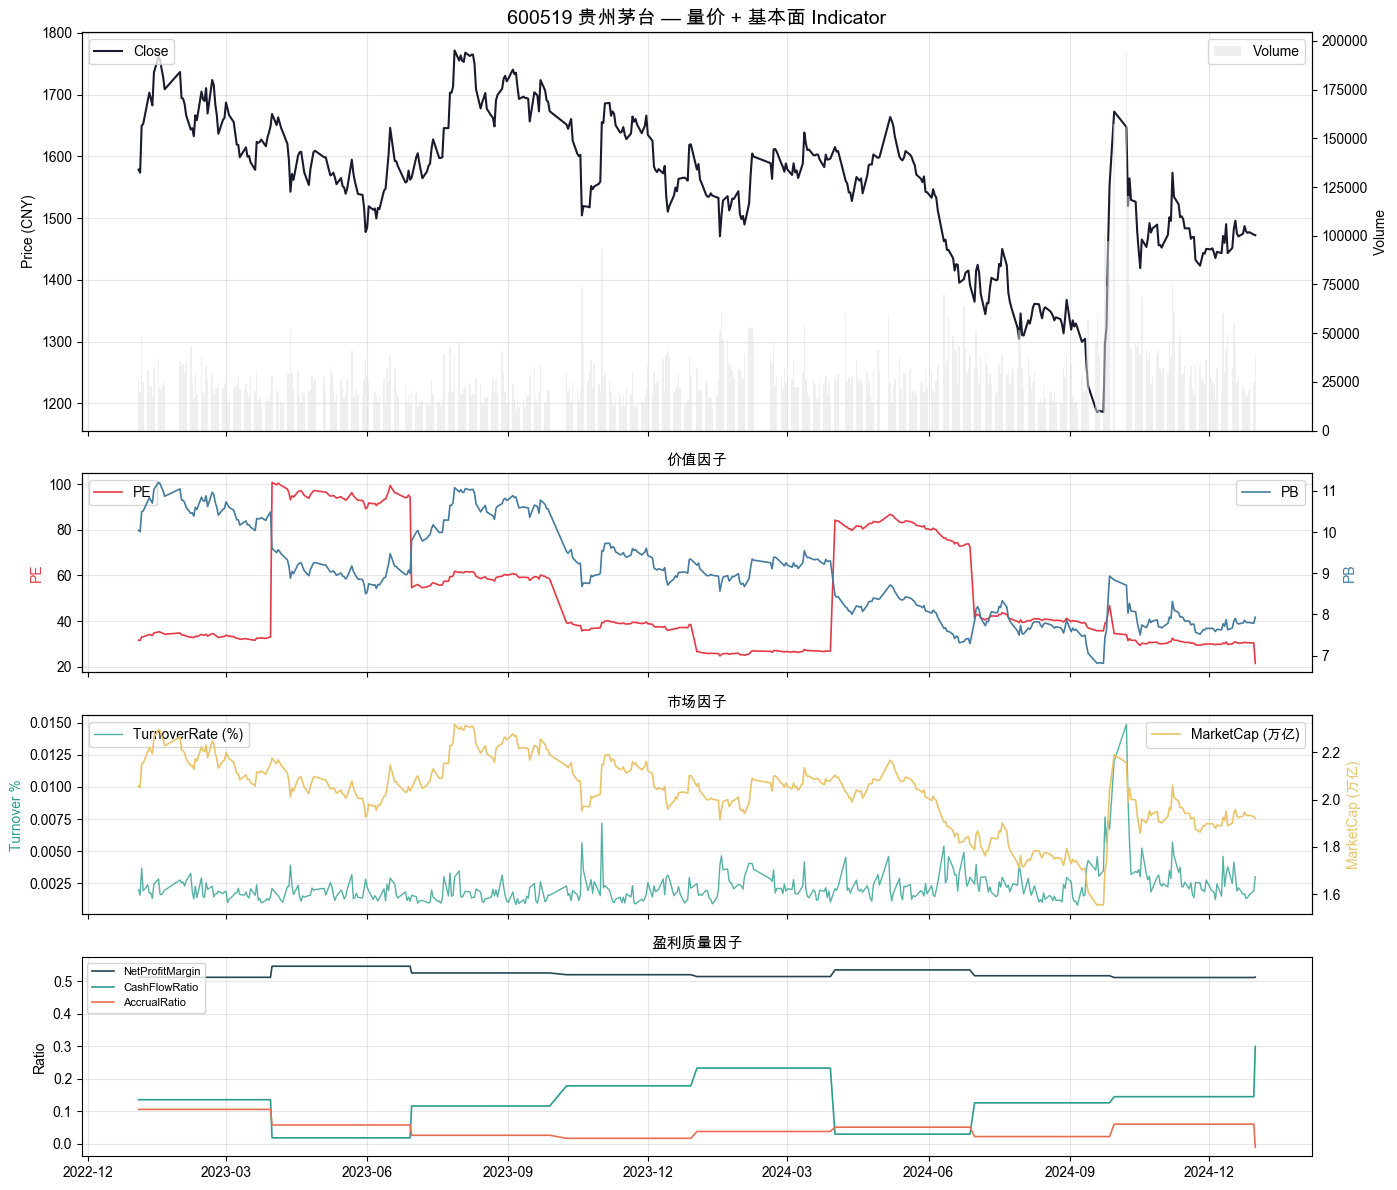

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1.5, 1.5, 1.5]})

# ── Panel 1: 收盘价 + 成交量 ──
ax_price = axes[0]
ax_vol = ax_price.twinx()

ax_price.plot(merged.index, merged["close"], color="#1a1a2e", linewidth=1.5, label="Close")
ax_vol.bar(merged.index, merged["volume"], color="#e0e0e0", alpha=0.5, width=1, label="Volume")
ax_price.set_ylabel("Price (CNY)")
ax_vol.set_ylabel("Volume")
ax_price.set_title("600519 贵州茅台 — 量价 + 基本面 Indicator", fontsize=14, fontweight="bold")
ax_price.legend(loc="upper left")
ax_vol.legend(loc="upper right")
ax_price.grid(True, alpha=0.3)

# ── Panel 2: 价值因子 PE / PB ──
ax_val = axes[1]
if "PE" in merged.columns:
    ax_val.plot(merged.index, merged["PE"], color="#e63946", linewidth=1.2, label="PE")
ax_pb = ax_val.twinx()
if "PB" in merged.columns:
    ax_pb.plot(merged.index, merged["PB"], color="#457b9d", linewidth=1.2, label="PB")
ax_val.set_ylabel("PE", color="#e63946")
ax_pb.set_ylabel("PB", color="#457b9d")
ax_val.legend(loc="upper left")
ax_pb.legend(loc="upper right")
ax_val.set_title("价值因子", fontsize=11)
ax_val.grid(True, alpha=0.3)

# ── Panel 3: 市场因子 TurnoverRate / MarketCap ──
ax_mkt = axes[2]
if "TurnoverRate" in merged.columns:
    ax_mkt.plot(merged.index, merged["TurnoverRate"] * 100, color="#2a9d8f",
                linewidth=1, alpha=0.8, label="TurnoverRate (%)")
ax_cap = ax_mkt.twinx()
if "MarketCap" in merged.columns:
    ax_cap.plot(merged.index, merged["MarketCap"] / 1e12, color="#e9c46a",
                linewidth=1.2, label="MarketCap (万亿)")
ax_mkt.set_ylabel("Turnover %", color="#2a9d8f")
ax_cap.set_ylabel("MarketCap (万亿)", color="#e9c46a")
ax_mkt.legend(loc="upper left")
ax_cap.legend(loc="upper right")
ax_mkt.set_title("市场因子", fontsize=11)
ax_mkt.grid(True, alpha=0.3)

# ── Panel 4: 盈利质量 NetProfitMargin / CashFlowRatio / AccrualRatio ──
ax_qual = axes[3]
colors = {"NetProfitMargin": "#264653", "CashFlowRatio": "#2a9d8f", "AccrualRatio": "#e76f51"}
for name, color in colors.items():
    if name in merged.columns:
        ax_qual.plot(merged.index, merged[name], color=color, linewidth=1.2, label=name)
ax_qual.set_ylabel("Ratio")
ax_qual.legend(loc="upper left", fontsize=8)
ax_qual.set_title("盈利质量因子", fontsize=11)
ax_qual.grid(True, alpha=0.3)
ax_qual.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_qual.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.tight_layout()
plt.show()

---
## 10. 数据存储结构

财务数据存储在 `~/.oxq/data/factor/financial/` 目录下，每只股票一个 Parquet 文件：

```
~/.oxq/data/factor/
├── macro/              # 宏观因子（World Bank）
│   ├── gdp.parquet
│   └── cpi.parquet
└── financial/          # 财务因子（按 symbol 分文件）
    ├── 600519.parquet   # 贵州茅台
    ├── 000858.parquet   # 五粮液
    ├── AAPL.parquet     # Apple
    └── MSFT.parquet     # Microsoft
```

可以通过环境变量 `OXQ_DATA_DIR` 或构造参数 `dest_dir` 自定义存储路径。

---
## 小结

| 组件 | 职责 |
|------|------|
| `EastMoneyFetcher` | A 股财务数据（东方财富 via akshare） |
| `YFinanceFinancialFetcher` | 美股财务数据（via yfinance） |
| `FactorDownloader` | 通用存储层（fetch + save + 增量合并） |
| `read_factor(sub="financial")` | 读取本地财务数据 |
| `FactorFetcher` | 统一 Protocol，支持自定义数据源 |

**核心设计原则**：

1. **report_date vs publish_date 严格分离** — 回测时用 `point_in_time=True` 避免未来函数偏差
2. **统一接口** — 所有数据源都实现 `FactorFetcher`，换数据源只需换 Fetcher
3. **Download-then-Read** — 下载与读取分离，策略执行不依赖网络
4. **增量更新** — 重复下载自动合并去重，无需手动管理
5. **Parquet schema evolution** — 未来新增因子列时，旧文件自动填充 NaN